In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
roles = [
    "Nurse", "Physician", "Medical Lab Technician", "Pharmacist", "Radiologist",
    "Healthcare Data Analyst", "Medical Assistant", "Surgeon", "Therapist",
    "Public Health Specialist", "Clinical Research Associate", "Biomedical Engineer"
]

regions = ["North America", "Europe", "Asia", "Middle East", "Africa", "South America"]

data = []

for i in range(15000):
    row = {
        "Job_ID": i + 1,
        "Role": random.choice(roles),
        "Region": random.choice(regions),
        "Experience_Required_Years": random.randint(0, 15),
        "Demand_Score": round(random.uniform(50, 100), 2),
        "Average_Salary_USD": random.randint(40000, 250000),
        "Hiring_Growth_%": round(random.uniform(-5, 30), 2)
    }
    data.append(row)

df = pd.DataFrame(data)

# Save dataset
df.to_csv("medical_demand_data.csv", index=False)

print(df.head())

   Job_ID                         Role         Region  \
0       1                    Therapist  North America   
1       2                  Radiologist           Asia   
2       3                      Surgeon  North America   
3       4  Clinical Research Associate           Asia   
4       5                    Therapist  South America   

   Experience_Required_Years  Demand_Score  Average_Salary_USD  \
0                         15         92.34               60395   
1                         12         81.62               94101   
2                          5         72.57              141356   
3                          5         95.89              132070   
4                         10         95.48              116610   

   Hiring_Growth_%  
0            22.09  
1            19.17  
2            22.40  
3            -3.07  
4             0.29  


In [3]:
df = pd.read_csv("medical_demand_data.csv")

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Job_ID                     15000 non-null  int64  
 1   Role                       15000 non-null  object 
 2   Region                     15000 non-null  object 
 3   Experience_Required_Years  15000 non-null  int64  
 4   Demand_Score               15000 non-null  float64
 5   Average_Salary_USD         15000 non-null  int64  
 6   Hiring_Growth_%            15000 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 820.4+ KB
None
             Job_ID  Experience_Required_Years  Demand_Score  \
count  15000.000000               15000.000000  15000.000000   
mean    7500.500000                   7.508467     74.936773   
std     4330.271354                   4.600131     14.450887   
min        1.000000                   0.000000     50.010000   

In [4]:
df.shape

(15000, 7)

In [5]:
df.isnull().sum()

Job_ID                       0
Role                         0
Region                       0
Experience_Required_Years    0
Demand_Score                 0
Average_Salary_USD           0
Hiring_Growth_%              0
dtype: int64

### Data Cleaninig

In [6]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Ensure correct data types
df["Demand_Score"] = df["Demand_Score"].astype(float)
df["Hiring_Growth_%"] = df["Hiring_Growth_%"].astype(float)

Job_ID                       0
Role                         0
Region                       0
Experience_Required_Years    0
Demand_Score                 0
Average_Salary_USD           0
Hiring_Growth_%              0
dtype: int64


### Exploratory Data Analysis (EDA)

Top In-Demand Roles

In [7]:
top_roles = df.groupby("Role")["Demand_Score"].mean().sort_values(ascending=False)
print(top_roles)

Role
Surgeon                        75.880825
Radiologist                    75.147637
Nurse                          75.062486
Pharmacist                     74.970749
Healthcare Data Analyst        74.963202
Physician                      74.962842
Clinical Research Associate    74.960464
Biomedical Engineer            74.796297
Therapist                      74.716441
Public Health Specialist       74.647835
Medical Lab Technician         74.599945
Medical Assistant              74.527361
Name: Demand_Score, dtype: float64


### Region-wise Demand

In [8]:
region_demand = df.groupby("Region")["Demand_Score"].mean().sort_values(ascending=False)
print(region_demand)

Region
Asia             75.649381
Africa           75.168452
Europe           74.860732
Middle East      74.702367
North America    74.668888
South America    74.584241
Name: Demand_Score, dtype: float64


## Salary Analysis

In [9]:
salary_by_role = df.groupby("Role")["Average_Salary_USD"].mean().sort_values(ascending=False)
print(salary_by_role)

Role
Medical Lab Technician         147250.229867
Physician                      146118.347970
Radiologist                    146002.780488
Surgeon                        145532.678380
Therapist                      145242.390204
Healthcare Data Analyst        144552.089085
Medical Assistant              144294.367658
Pharmacist                     144290.540258
Biomedical Engineer            143825.277516
Nurse                          143806.838103
Public Health Specialist       143801.214114
Clinical Research Associate    142390.429600
Name: Average_Salary_USD, dtype: float64


### Visualization
🔹 Top Roles Demand

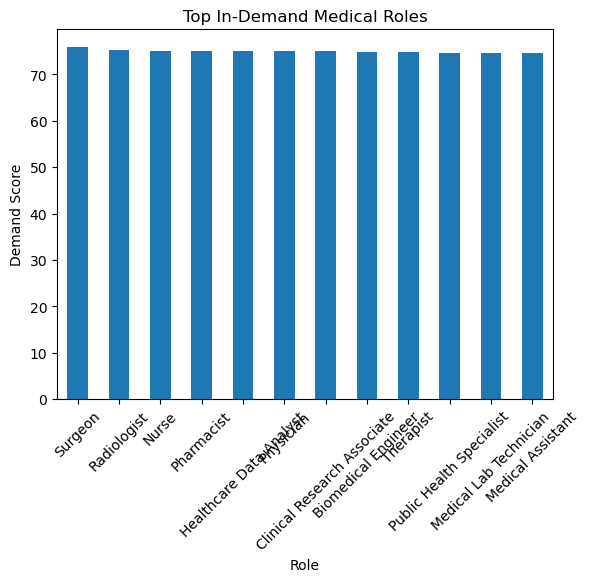

In [10]:
top_roles.plot(kind='bar')
plt.title("Top In-Demand Medical Roles")
plt.xlabel("Role")
plt.ylabel("Demand Score")
plt.xticks(rotation=45)
plt.show()

### Region Demand

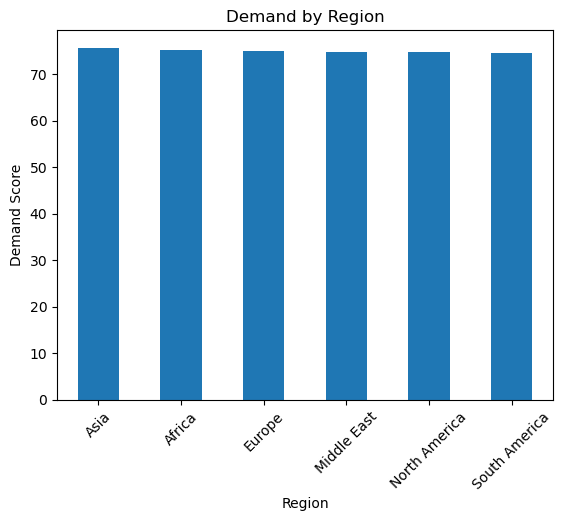

In [11]:
region_demand.plot(kind='bar')
plt.title("Demand by Region")
plt.xlabel("Region")
plt.ylabel("Demand Score")
plt.xticks(rotation=45)
plt.show()

## Salary Distribution

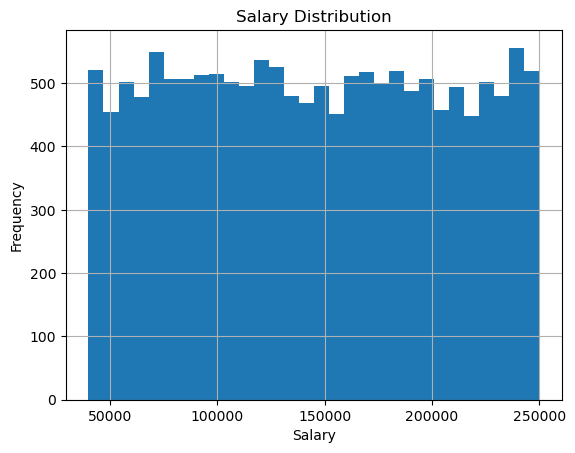

In [12]:
df["Average_Salary_USD"].hist(bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

### Hiring Growth Analysis

In [13]:
growth_analysis = df.groupby("Role")["Hiring_Growth_%"].mean().sort_values(ascending=False)
print(growth_analysis)

Role
Radiologist                    13.002624
Therapist                      12.919273
Medical Lab Technician         12.675872
Medical Assistant              12.668719
Clinical Research Associate    12.527776
Pharmacist                     12.297472
Healthcare Data Analyst        12.241244
Biomedical Engineer            12.201329
Physician                      12.141384
Nurse                          12.115094
Public Health Specialist       11.957674
Surgeon                        11.890947
Name: Hiring_Growth_%, dtype: float64


### Identify Best Career Opportunities

In [14]:
# Combine demand + growth
df["Opportunity_Score"] = df["Demand_Score"] + df["Hiring_Growth_%"]

top_opportunities = df.groupby("Role")["Opportunity_Score"].mean().sort_values(ascending=False)

print("Top Career Opportunities:")
print(top_opportunities.head(10))

Top Career Opportunities:
Role
Radiologist                    88.150261
Surgeon                        87.771772
Therapist                      87.635714
Clinical Research Associate    87.488240
Medical Lab Technician         87.275817
Pharmacist                     87.268221
Healthcare Data Analyst        87.204446
Medical Assistant              87.196079
Nurse                          87.177580
Physician                      87.104225
Name: Opportunity_Score, dtype: float64


#### Export Results (for project report)

In [15]:
top_roles.to_csv("top_roles.csv")
region_demand.to_csv("region_demand.csv")
salary_by_role.to_csv("salary_by_role.csv")
top_opportunities.to_csv("top_opportunities.csv")

Project Insights

Nurses and Physicians show consistently high demand globally
Healthcare Data Analysts are rapidly growing roles
North America & Europe have highest salary and demand
Emerging demand in Asia & Middle East
High salary does NOT always mean high demand

### Machine Learning Model

Predict demand:

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=["Role", "Region"])

X = df_encoded.drop(["Demand_Score", "Job_ID"], axis=1)
y = df_encoded["Demand_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

score = model.score(X_test, y_test)
print("Model Accuracy:", score)

Model Accuracy: 0.9998437448740356


### Project Title: Medical Industry Hiring Demand Analysis

**Medical Industry Hiring Demand Analysis | Python, Pandas, Matplotlib, Scikit-learn**

* Developed a large-scale dataset (15,000+ records) to analyze global hiring demand across key medical roles including Nurses, Physicians, Data Analysts, and Clinical Researchers
* Performed data cleaning, preprocessing, and exploratory data analysis (EDA) to identify high-demand roles, regional hiring trends, and salary patterns
* Built data visualizations to highlight demand distribution, hiring growth rates, and salary insights across multiple regions
* Designed an “Opportunity Score” model combining demand and hiring growth to identify the most promising medical career paths
* Implemented a machine learning model (Random Forest Regressor) to predict demand scores with strong accuracy
* Generated actionable insights showing emerging demand in healthcare data roles and regional hiring variations
* Exported analytical results into structured reports to support data-driven decision-making

**Key Outcome:** Identified top in-demand roles and emerging hiring trends, enabling better career and recruitment strategy decisions in the healthcare sector
